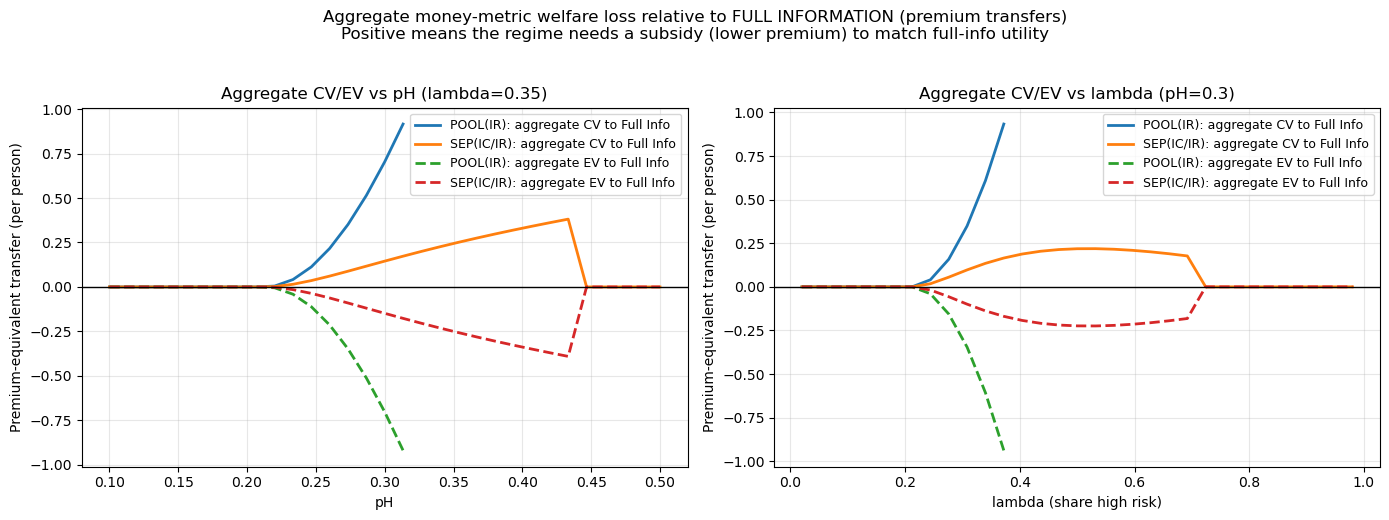

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize_scalar

# =========================
# PARAMETERS
# =========================
W     = 100.0
Lloss = 40.0
pL    = 0.08
gamma = 2.0

# for the two sweeps
lam_fixed = 0.35   # sweep pH holding lambda fixed
pH_fixed  = 0.30   # sweep lambda holding pH fixed

# numerical tolerances
TOL = 1e-10

# =========================
# MODEL
# =========================
def u(c, gamma):
    c = np.maximum(c, 1e-12)
    if abs(gamma - 1.0) < 1e-12:
        return np.log(c)
    return (c ** (1 - gamma)) / (1 - gamma)

def EU(W, Lloss, p, q, pi, gamma):
    cH = W - pi
    cS = W - pi - (1 - q) * Lloss
    return (1 - p) * u(cH, gamma) + p * u(cS, gamma)

def EU0(W, Lloss, p, gamma):
    return (1 - p) * u(W, gamma) + p * u(W - Lloss, gamma)

def cost(Lloss, p, q):
    # actuarially fair premium
    return p * q * Lloss

def fullinfo_contract(Lloss, p):
    # full insurance benchmark
    return {"q": 1.0, "pi": cost(Lloss, p, 1.0)}

# =========================
# POOLING + IR (one contract)
# =========================
def pooling_opt(W, Lloss, pL, pH, lam, gamma, require_IR=True):
    pbar = lam * pH + (1 - lam) * pL
    EU0L, EU0H = EU0(W, Lloss, pL, gamma), EU0(W, Lloss, pH, gamma)

    def objective(q):
        q = np.clip(q, 0.0, 1.0)
        pi = cost(Lloss, pbar, q)
        EUL = EU(W, Lloss, pL, q, pi, gamma)
        EUH = EU(W, Lloss, pH, q, pi, gamma)
        if require_IR and (EUL < EU0L - 1e-12 or EUH < EU0H - 1e-12):
            return 1e9  # infeasible
        EUavg = (1 - lam) * EUL + lam * EUH
        return -EUavg

    res = minimize_scalar(objective, bounds=(0.0, 1.0), method="bounded")
    if not res.success:
        return None

    q = float(res.x)
    pi = cost(Lloss, pbar, q)

    # feasibility check
    if require_IR:
        if EU(W, Lloss, pL, q, pi, gamma) < EU0(W, Lloss, pL, gamma) - 1e-10:
            return None
        if EU(W, Lloss, pH, q, pi, gamma) < EU0(W, Lloss, pH, gamma) - 1e-10:
            return None

    return {"q": q, "pi": pi, "pbar": pbar}

# =========================
# SEPARATING + IC/IR (MD screening)
# We impose "no distortion at the top": qH = 1.
# Choose qL, then solve premia from:
# - IC_H binds
# - aggregate break-even binds
# =========================
def solve_premia_given_qL(W, Lloss, pL, pH, lam, gamma, qL):
    qH = 1.0
    CL = cost(Lloss, pL, qL)
    CH = cost(Lloss, pH, qH)
    cost_avg = (1 - lam) * CL + lam * CH

    def piH_from_piL(piL):
        return (cost_avg - (1 - lam) * piL) / lam

    def F(piL):
        piH = piH_from_piL(piL)
        return EU(W, Lloss, pH, qH, piH, gamma) - EU(W, Lloss, pH, qL, piL, gamma)  # IC_H binds

    # feasible piL bounds (keep sick consumption positive)
    piL_min = 0.0
    piL_max = min(W - 1e-8, W - (1 - qL) * Lloss - 1e-8)
    if piL_max <= piL_min:
        return None

    fmin, fmax = F(piL_min), F(piL_max)
    if np.isnan(fmin) or np.isnan(fmax) or fmin * fmax > 0:
        return None

    piL = brentq(F, piL_min, piL_max, maxiter=200)
    piH = piH_from_piL(piL)

    # feasibility for H too
    if piH < 0 or piH > W - 1e-8 or piH > W - (1 - qH) * Lloss - 1e-8:
        return None

    return {"qL": qL, "piL": piL, "qH": 1.0, "piH": piH}

def separating_opt_MD(W, Lloss, pL, pH, lam, gamma):
    EU0L, EU0H = EU0(W, Lloss, pL, gamma), EU0(W, Lloss, pH, gamma)

    def objective(qL):
        qL = np.clip(qL, 0.0, 1.0)
        sol = solve_premia_given_qL(W, Lloss, pL, pH, lam, gamma, qL)
        if sol is None:
            return 1e9

        qH, piH = sol["qH"], sol["piH"]
        piL = sol["piL"]

        # IR
        EUL = EU(W, Lloss, pL, qL, piL, gamma)
        EUH_ = EU(W, Lloss, pH, qH, piH, gamma)
        if EUL < EU0L - 1e-12 or EUH_ < EU0H - 1e-12:
            return 1e9

        # IC_L (usually slack, but enforce)
        if EUL < EU(W, Lloss, pL, qH, piH, gamma) - 1e-12:
            return 1e9

        EUavg = (1 - lam) * EUL + lam * EUH_
        return -EUavg

    res = minimize_scalar(objective, bounds=(0.0, 1.0), method="bounded")
    if not res.success:
        return None

    qL = float(res.x)
    sol = solve_premia_given_qL(W, Lloss, pL, pH, lam, gamma, qL)
    return sol

# =========================
# Money-metric welfare: premium-based CV and EV
# (premium shift is equivalent to adding same amount to consumption in both states)
# =========================
def feasible_T_bounds_premium(W, Lloss, q, pi):
    # new premium = pi - T, need sick consumption positive
    lower = pi - (W - (1 - q) * Lloss) + 1e-8
    upper = pi + W
    return lower, upper

def premium_transfer_to_match(W, Lloss, p, gamma, contract_from, target_EU):
    q, pi = contract_from["q"], contract_from["pi"]
    Tmin, Tmax = feasible_T_bounds_premium(W, Lloss, q, pi)

    def f(T):
        return EU(W, Lloss, p, q, pi - T, gamma) - target_EU

    fmin, fmax = f(Tmin), f(Tmax)
    if np.isnan(fmin) or np.isnan(fmax) or fmin * fmax > 0:
        return np.nan
    return brentq(f, Tmin, Tmax, maxiter=500)

def CV_premium(W, Lloss, p, gamma, baseline_contract, policy_contract):
    # subsidy to POLICY so that utility equals BASELINE utility
    target = EU(W, Lloss, p, baseline_contract["q"], baseline_contract["pi"], gamma)
    return premium_transfer_to_match(W, Lloss, p, gamma, policy_contract, target)

def EV_premium(W, Lloss, p, gamma, baseline_contract, policy_contract):
    # subsidy to BASELINE so that utility equals POLICY utility
    target = EU(W, Lloss, p, policy_contract["q"], policy_contract["pi"], gamma)
    return premium_transfer_to_match(W, Lloss, p, gamma, baseline_contract, target)

# =========================
# Aggregate CV/EV relative to FULL INFO
# For each type i: compare regime contract to full-info contract for that type.
# Then aggregate with (1-lam, lam).
# =========================
def agg_CV_EV_to_fullinfo(pH, lam, regime, require_IR_pool=True):
    """
    regime: "POOL" or "SEP"
    Returns aggregate CV and EV (premium metric) needed to equate regime to full-info.
    Positive CV means regime needs a subsidy to match full-info utility.
    """
    FI_L = fullinfo_contract(Lloss, pL)
    FI_H = fullinfo_contract(Lloss, pH)

    if regime == "POOL":
        pool = pooling_opt(W, Lloss, pL, pH, lam, gamma, require_IR=require_IR_pool)
        if pool is None:
            return None
        reg_L = {"q": pool["q"], "pi": pool["pi"]}
        reg_H = {"q": pool["q"], "pi": pool["pi"]}  # same contract
    elif regime == "SEP":
        sep = separating_opt_MD(W, Lloss, pL, pH, lam, gamma)
        if sep is None:
            return None
        reg_L = {"q": sep["qL"], "pi": sep["piL"]}
        reg_H = {"q": sep["qH"], "pi": sep["piH"]}  # qH=1
    else:
        raise ValueError("regime must be POOL or SEP")

    CV_L = CV_premium(W, Lloss, pL, gamma, FI_L, reg_L)
    EV_L = EV_premium(W, Lloss, pL, gamma, FI_L, reg_L)
    CV_H = CV_premium(W, Lloss, pH, gamma, FI_H, reg_H)
    EV_H = EV_premium(W, Lloss, pH, gamma, FI_H, reg_H)

    CV_agg = (1 - lam) * CV_L + lam * CV_H
    EV_agg = (1 - lam) * EV_L + lam * EV_H

    return {"CV_agg": CV_agg, "EV_agg": EV_agg}

# =========================
# PLOTS (only aggregate CV/EV)
# =========================
def plot_aggregate_CV_EV():
    # ---- sweep pH ----
    pH_grid = np.linspace(0.10, 0.50, 31)
    CV_pool_pH, EV_pool_pH = [], []
    CV_sep_pH,  EV_sep_pH  = [], []

    for pH in pH_grid:
        out_pool = agg_CV_EV_to_fullinfo(pH, lam_fixed, regime="POOL", require_IR_pool=True)
        out_sep  = agg_CV_EV_to_fullinfo(pH, lam_fixed, regime="SEP",  require_IR_pool=True)
        CV_pool_pH.append(np.nan if out_pool is None else out_pool["CV_agg"])
        EV_pool_pH.append(np.nan if out_pool is None else out_pool["EV_agg"])
        CV_sep_pH.append(np.nan if out_sep  is None else out_sep["CV_agg"])
        EV_sep_pH.append(np.nan if out_sep  is None else out_sep["EV_agg"])

    # ---- sweep lambda ----
    lam_grid = np.linspace(0.02, 0.98, 31)
    CV_pool_lam, EV_pool_lam = [], []
    CV_sep_lam,  EV_sep_lam  = [], []

    for lam_here in lam_grid:
        out_pool = agg_CV_EV_to_fullinfo(pH_fixed, lam_here, regime="POOL", require_IR_pool=True)
        out_sep  = agg_CV_EV_to_fullinfo(pH_fixed, lam_here, regime="SEP",  require_IR_pool=True)
        CV_pool_lam.append(np.nan if out_pool is None else out_pool["CV_agg"])
        EV_pool_lam.append(np.nan if out_pool is None else out_pool["EV_agg"])
        CV_sep_lam.append(np.nan if out_sep  is None else out_sep["CV_agg"])
        EV_sep_lam.append(np.nan if out_sep  is None else out_sep["EV_agg"])

    # ---- plot ----
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(pH_grid, CV_pool_pH, lw=2, label="POOL(IR): aggregate CV to Full Info")
    ax[0].plot(pH_grid, CV_sep_pH,  lw=2, label="SEP(IC/IR): aggregate CV to Full Info")
    ax[0].plot(pH_grid, EV_pool_pH, lw=2, ls="--", label="POOL(IR): aggregate EV to Full Info")
    ax[0].plot(pH_grid, EV_sep_pH,  lw=2, ls="--", label="SEP(IC/IR): aggregate EV to Full Info")
    ax[0].axhline(0, color="k", lw=1)
    ax[0].set_title(f"Aggregate CV/EV vs pH (lambda={lam_fixed})")
    ax[0].set_xlabel("pH")
    ax[0].set_ylabel("Premium-equivalent transfer (per person)")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend(fontsize=9)

    ax[1].plot(lam_grid, CV_pool_lam, lw=2, label="POOL(IR): aggregate CV to Full Info")
    ax[1].plot(lam_grid, CV_sep_lam,  lw=2, label="SEP(IC/IR): aggregate CV to Full Info")
    ax[1].plot(lam_grid, EV_pool_lam, lw=2, ls="--", label="POOL(IR): aggregate EV to Full Info")
    ax[1].plot(lam_grid, EV_sep_lam,  lw=2, ls="--", label="SEP(IC/IR): aggregate EV to Full Info")
    ax[1].axhline(0, color="k", lw=1)
    ax[1].set_title(f"Aggregate CV/EV vs lambda (pH={pH_fixed})")
    ax[1].set_xlabel("lambda (share high risk)")
    ax[1].set_ylabel("Premium-equivalent transfer (per person)")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend(fontsize=9)

    plt.suptitle(
        "Aggregate money-metric welfare loss relative to FULL INFORMATION (premium transfers)\n"
        "Positive means the regime needs a subsidy (lower premium) to match full-info utility",
        y=1.03
    )
    plt.tight_layout()
    plt.show()


# =========================
# RUN
# =========================
plot_aggregate_CV_EV()

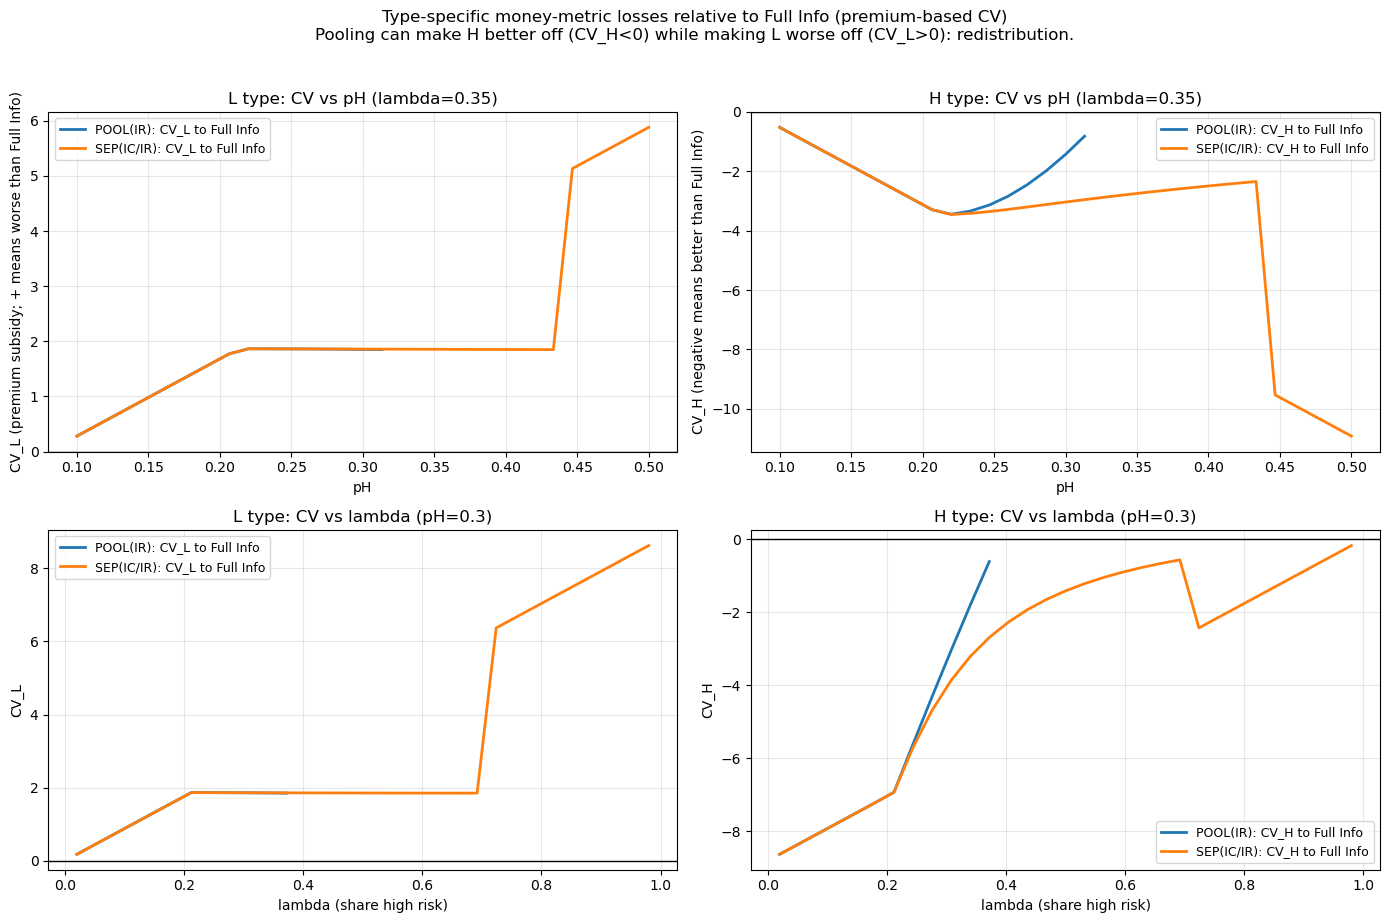

In [2]:
def type_CV_to_fullinfo(pH, lam, regime, require_IR_pool=True):
    """
    Returns (CV_L, CV_H) where CV_i is the premium subsidy needed under 'regime'
    to reach FULL-INFO utility for type i.
    """
    FI_L = fullinfo_contract(Lloss, pL)
    FI_H = fullinfo_contract(Lloss, pH)

    if regime == "POOL":
        pool = pooling_opt(W, Lloss, pL, pH, lam, gamma, require_IR=require_IR_pool)
        if pool is None:
            return (np.nan, np.nan)
        reg_L = {"q": pool["q"], "pi": pool["pi"]}
        reg_H = {"q": pool["q"], "pi": pool["pi"]}

    elif regime == "SEP":
        sep = separating_opt_MD(W, Lloss, pL, pH, lam, gamma)
        if sep is None:
            return (np.nan, np.nan)
        reg_L = {"q": sep["qL"], "pi": sep["piL"]}
        reg_H = {"q": sep["qH"], "pi": sep["piH"]}

    else:
        raise ValueError("regime must be 'POOL' or 'SEP'")

    CV_L = CV_premium(W, Lloss, pL, gamma, FI_L, reg_L)
    CV_H = CV_premium(W, Lloss, pH, gamma, FI_H, reg_H)
    return (CV_L, CV_H)


def plot_type_specific_CV_panels(lam_fixed=0.35, pH_fixed=0.30,
                                 pH_min=0.10, pH_max=0.50, n_pH=31,
                                 lam_min=0.02, lam_max=0.98, n_lam=31,
                                 require_IR_pool=True):
    # ----- sweep pH (lambda fixed)
    pH_grid = np.linspace(pH_min, pH_max, n_pH)
    CVL_pool_pH, CVH_pool_pH = [], []
    CVL_sep_pH,  CVH_sep_pH  = [], []

    for pH in pH_grid:
        CVL, CVH = type_CV_to_fullinfo(pH, lam_fixed, "POOL", require_IR_pool=require_IR_pool)
        CVL_pool_pH.append(CVL); CVH_pool_pH.append(CVH)

        CVL, CVH = type_CV_to_fullinfo(pH, lam_fixed, "SEP", require_IR_pool=require_IR_pool)
        CVL_sep_pH.append(CVL);  CVH_sep_pH.append(CVH)

    # ----- sweep lambda (pH fixed)
    lam_grid = np.linspace(lam_min, lam_max, n_lam)
    CVL_pool_lam, CVH_pool_lam = [], []
    CVL_sep_lam,  CVH_sep_lam  = [], []

    for lam in lam_grid:
        CVL, CVH = type_CV_to_fullinfo(pH_fixed, lam, "POOL", require_IR_pool=require_IR_pool)
        CVL_pool_lam.append(CVL); CVH_pool_lam.append(CVH)

        CVL, CVH = type_CV_to_fullinfo(pH_fixed, lam, "SEP", require_IR_pool=require_IR_pool)
        CVL_sep_lam.append(CVL);  CVH_sep_lam.append(CVH)

    # ----- plot: 2x2 panels
    fig, ax = plt.subplots(2, 2, figsize=(14, 9))

    # (1) L-type CV vs pH
    ax[0,0].plot(pH_grid, CVL_pool_pH, lw=2, label="POOL(IR): CV_L to Full Info")
    ax[0,0].plot(pH_grid, CVL_sep_pH,  lw=2, label="SEP(IC/IR): CV_L to Full Info")
    ax[0,0].axhline(0, color="k", lw=1)
    ax[0,0].set_title(f"L type: CV vs pH (lambda={lam_fixed})")
    ax[0,0].set_xlabel("pH")
    ax[0,0].set_ylabel("CV_L (premium subsidy; + means worse than Full Info)")
    ax[0,0].grid(True, alpha=0.3)
    ax[0,0].legend(fontsize=9)

    # (2) H-type CV vs pH
    ax[0,1].plot(pH_grid, CVH_pool_pH, lw=2, label="POOL(IR): CV_H to Full Info")
    ax[0,1].plot(pH_grid, CVH_sep_pH,  lw=2, label="SEP(IC/IR): CV_H to Full Info")
    ax[0,1].axhline(0, color="k", lw=1)
    ax[0,1].set_title(f"H type: CV vs pH (lambda={lam_fixed})")
    ax[0,1].set_xlabel("pH")
    ax[0,1].set_ylabel("CV_H (negative means better than Full Info)")
    ax[0,1].grid(True, alpha=0.3)
    ax[0,1].legend(fontsize=9)

    # (3) L-type CV vs lambda
    ax[1,0].plot(lam_grid, CVL_pool_lam, lw=2, label="POOL(IR): CV_L to Full Info")
    ax[1,0].plot(lam_grid, CVL_sep_lam,  lw=2, label="SEP(IC/IR): CV_L to Full Info")
    ax[1,0].axhline(0, color="k", lw=1)
    ax[1,0].set_title(f"L type: CV vs lambda (pH={pH_fixed})")
    ax[1,0].set_xlabel("lambda (share high risk)")
    ax[1,0].set_ylabel("CV_L")
    ax[1,0].grid(True, alpha=0.3)
    ax[1,0].legend(fontsize=9)

    # (4) H-type CV vs lambda
    ax[1,1].plot(lam_grid, CVH_pool_lam, lw=2, label="POOL(IR): CV_H to Full Info")
    ax[1,1].plot(lam_grid, CVH_sep_lam,  lw=2, label="SEP(IC/IR): CV_H to Full Info")
    ax[1,1].axhline(0, color="k", lw=1)
    ax[1,1].set_title(f"H type: CV vs lambda (pH={pH_fixed})")
    ax[1,1].set_xlabel("lambda (share high risk)")
    ax[1,1].set_ylabel("CV_H")
    ax[1,1].grid(True, alpha=0.3)
    ax[1,1].legend(fontsize=9)

    plt.suptitle(
        "Type-specific money-metric losses relative to Full Info (premium-based CV)\n"
        "Pooling can make H better off (CV_H<0) while making L worse off (CV_L>0): redistribution.",
        y=1.02
    )
    plt.tight_layout()
    plt.show()


# Run it
plot_type_specific_CV_panels(lam_fixed=lam_fixed, pH_fixed=pH_fixed, require_IR_pool=True)